# XGBoost - PRE-TRAINING IKLIM (ERA5) Interval 1 Jam


In [1]:
# Sel 1: Impor Library dan Setup Lingkungan
import os
import sys
import json
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import optuna
import shap
import scipy.stats as stats

from pathlib import Path
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_auc_score, 
    roc_curve, 
    precision_recall_curve, 
    auc, 
    confusion_matrix,
    brier_score_loss, 
    mean_squared_error,
    mean_absolute_error, 
    r2_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger()
logger.info("Kerangka Pemodelan Prediksi Curah Hujan Akumulasi 3-Jam Dimulai...")


2026-07-07 16:23:02,390 - INFO - Kerangka Pemodelan Prediksi Curah Hujan Akumulasi 3-Jam Dimulai...


## Tahap 2: Konfigurasi Global & Konstanta

Sel ini mendefinisikan seluruh variabel kontrol untuk *pipeline*. Anda bisa mengganti mode berjalannya notebook (`RUN_MODE`) menjadi mode cepat (*fast-test*) atau mode penuh (*pipeline_test*), serta menentukan jumlah *trials* Optuna.

In [2]:
# Sel 2: Konfigurasi Global
# Mode eksekusi: 
# - "FULL_TRAIN": Untuk optimasi dan pelatihan menyeluruh
# - "PIPELINE_TEST": Untuk uji coba cepat di Lokal (data dipotong & uji coba dibatasi)
RUN_MODE = "FULL_TRAIN"  # Ubah ke "PIPELINE_TEST" untuk uji coba cepat
SEED = 281225

# Batas ambang curah hujan untuk klasifikasi
RAIN_THRESHOLD = 0.2

# TRAIN: Ambil porsi terbesar (2005 - 2020 = 16 Tahun Data)
# Porsi panjang ini wajib agar AI mengenali segala jenis anomali iklim ekstrem masa lalu
PRETRAIN__TRAIN_START = '2005-01-01'
PRETRAIN__TRAIN_END   = '2020-12-31'

# VALIDATION: Gunakan rentang 3 tahun setelahnya (2021 - 2023)
# Validasi ini mencakup dinamika ekstrem: La Nina basah (2021-2022) & El Nino kering (2023)
PRETRAIN__VAL_START   = '2021-01-01'
PRETRAIN__VAL_END     = '2023-12-31'

# TEST: Gunakan data paling terbaru untuk pengujian murni
PRETRAIN__TEST_START  = '2024-01-01'
PRETRAIN__TEST_END    = '2025-12-31'  # Sesuaikan ke akhir tahun data terbaru Anda

FINETUNE_TRAIN_START = '2025-01-01'
FINETUNE_TRAIN_END   = '2026-01-15'
FINETUNE_VAL_START   = '2026-01-16'
FINETUNE_VAL_END     = '2026-04-05'
FINETUNE_TEST_START  = '2026-04-06'
FINETUNE_TEST_END    = '2026-05-31' 

# [Khusus LSTM] Panjang urutan waktu (sequence) ke belakang
LOOKBACK = 24
# ==========================================

# =====================================================================
# KONFIGURASI FITUR ERA5 MAPPING (Hanya ERA5, Tanpa ERA5-Land)
# =====================================================================
ERA5_FEATURES_MAPPING = {
    'temperature_era5': 'temperature',
    'humidity_era5': 'humidity',
    'dewpoint_era5': 'dewpoint',
    'rain_mm': 'rainrate',
    'sealevel_pressure_era5': 'pressure',
    'u10_era5': 'era5_u_wind',
    'v10_era5': 'era5_v_wind',
    'cloud_cover_era5': 'era5_cloud_cover',
    'cape_era5': 'era5_cape',
    'total_column_water_vapour_era5': 'era5_tcwv',
    'sunshine_duration_era5': 'era5_sunshine'
}

# Modul Bias Correction
ENABLE_BIAS_CORRECTION = True
ENABLE_DYNAMIC_BIAS_MODEL = True

if RUN_MODE == "PIPELINE_TEST":
    OPTUNA_TRIALS = 5
    EPOCHS = 2
else:
    OPTUNA_TRIALS = 30
    EPOCHS = 50

BASE_OUTPUT_DIR = Path('outputs_xgboost')

import random
random.seed(SEED)
np.random.seed(SEED)
import tensorflow as tf
tf.random.set_seed(SEED)


2026-07-07 16:23:05.038233: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783441385.352384      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783441385.443198      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783441386.214628      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783441386.214699      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783441386.214703      16 computation_placer.cc:177] computation placer alr

## Tahap 3: Mesin Evaluasi Terpadu (*ModelEvaluator*)

Ini adalah mesin (*engine*) utama untuk melakukan pelaporan hasil model. Kelas ini bertanggung jawab menghitung semua metrik meteorologi (CSI, POD, FAR), metrik klasifikasi (ROC-AUC), metrik regresi (RMSE), serta menyimpan seluruh grafik evaluasi dan kurva kalibrasi secara otomatis ke folder `outputs_*/`.

In [3]:
# Sel 3: Mesin Evaluasi Terpadu (Unified Evaluation Engine)
def fit_best_calibrator(y_val, val_probs):
    from sklearn.linear_model import LogisticRegression
    from sklearn.isotonic import IsotonicRegression
    from sklearn.metrics import brier_score_loss
    
    # Platt
    platt = LogisticRegression()
    try:
        platt.fit(val_probs.reshape(-1, 1), y_val)
        platt_probs = platt.predict_proba(val_probs.reshape(-1, 1))[:, 1]
        platt_brier = brier_score_loss(y_val, platt_probs)
    except:
        platt = None
        platt_brier = 999
        
    # Isotonic
    iso = IsotonicRegression(out_of_bounds='clip')
    try:
        iso.fit(val_probs, y_val)
        iso_probs = iso.predict(val_probs)
        iso_brier = brier_score_loss(y_val, iso_probs)
    except:
        iso = None
        iso_brier = 999
        
    raw_brier = brier_score_loss(y_val, val_probs)
    
    logger.info(f"[Calibrator Selection] Brier scores - Raw: {raw_brier:.4f}, Platt: {platt_brier:.4f}, Isotonic: {iso_brier:.4f}")
    
    if iso_brier <= platt_brier and iso_brier < raw_brier:
        logger.info("[Calibrator Selection] Selected Isotonic Calibrator")
        return iso, "Isotonic"
    elif platt_brier < iso_brier and platt_brier < raw_brier:
        logger.info("[Calibrator Selection] Selected Platt Calibrator")
        return platt, "Platt"
    else:
        logger.info("[Calibrator Selection] Selected Raw Calibrator (No calibration applied)")
        return None, "Raw"

def apply_calibrator(calibrator, calibrator_type, probs):
    if calibrator_type == "Isotonic":
        return calibrator.predict(probs)
    elif calibrator_type == "Platt":
        return calibrator.predict_proba(probs.reshape(-1, 1))[:, 1]
    else:
        return probs.copy()

class ModelEvaluator:
    def __init__(self):
        self.base_dir = BASE_OUTPUT_DIR
        self.dirs = {
            'models': self.base_dir / 'models',
            'models_clf': self.base_dir / 'models' / 'classifier',
            'models_reg': self.base_dir / 'models' / 'regressor',
            'models_cal': self.base_dir / 'models' / 'calibration',
            'metrics': self.base_dir / 'metrics',
            'reports': self.base_dir / 'reports',
            'plots': self.base_dir / 'plots',
        }
        
        for d in self.dirs.values():
            d.mkdir(parents=True, exist_ok=True)
            
    def calc_meteorological_metrics(self, y_true, y_pred):
        hits = np.sum((y_pred == 1) & (y_true == 1))
        misses = np.sum((y_pred == 0) & (y_true == 1))
        false_alarms = np.sum((y_pred == 1) & (y_true == 0))
        correct_negatives = np.sum((y_pred == 0) & (y_true == 0))
        
        total = len(y_true)
        hits_random = ((hits + misses) * (hits + false_alarms)) / (total + 1e-9)
        
        csi = hits / (hits + misses + false_alarms + 1e-9)
        pod = hits / (hits + misses + 1e-9)
        far = false_alarms / (hits + false_alarms + 1e-9)
        ets = (hits - hits_random) / (hits + misses + false_alarms - hits_random + 1e-9)
        hss = 2 * (hits * correct_negatives - misses * false_alarms) / ((hits + misses) * (misses + correct_negatives) + (hits + false_alarms) * (false_alarms + correct_negatives) + 1e-9)
        
        return {'CSI': float(csi), 'POD': float(pod), 'FAR': float(far), 'ETS': float(ets), 'HSS': float(hss)}

    def calc_hydrological_metrics(self, y_true, y_pred):
        if len(y_true) < 2: return {'NSE': 0.0, 'KGE': 0.0, 'Correlation': 0.0}
        mean_obs, mean_sim = np.mean(y_true), np.mean(y_pred)
        std_obs, std_sim = np.std(y_true), np.std(y_pred)
        
        numerator = np.sum((y_true - y_pred)**2)
        denominator = np.sum((y_true - mean_obs)**2)
        nse = 1 - (numerator / (denominator + 1e-9))
        
        if std_obs > 0 and std_sim > 0:
            r = np.corrcoef(y_true, y_pred)[0, 1]
            alpha = std_sim / (std_obs + 1e-9)
            beta = mean_sim / (mean_obs + 1e-9)
            kge = 1 - np.sqrt((r - 1)**2 + (beta - 1)**2 + (alpha - 1)**2)
        else:
            r, kge = 0.0, 0.0
            
        return {'NSE': float(nse), 'KGE': float(kge), 'Correlation': float(r)}

    def evaluate_classification(self, y_true, y_prob_uncal, y_prob_cal, y_pred):
        logger.info("Menghitung metrik klasifikasi...")
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        roc_auc = roc_auc_score(y_true, y_prob_cal)
        
        brier_uncal = brier_score_loss(y_true, y_prob_uncal)
        brier_cal = brier_score_loss(y_true, y_prob_cal)
        
        precision_arr, recall_arr, _ = precision_recall_curve(y_true, y_prob_cal)
        pr_auc = auc(recall_arr, precision_arr)
        
        metrics = {
            'Accuracy': float(acc), 
            'Precision': float(prec), 
            'Recall': float(rec), 
            'F1 Score': float(f1), 
            'ROC-AUC': float(roc_auc), 
            'PR-AUC': float(pr_auc), 
            'Brier Score (Uncalibrated)': float(brier_uncal),
            'Brier Score (Calibrated)': float(brier_cal)
        }
        
        with open(self.dirs['metrics'] / 'classification_metrics.json', 'w') as f:
            json.dump(metrics, f, indent=4)
            
        meteo_metrics = self.calc_meteorological_metrics(y_true, y_pred)
        with open(self.dirs['metrics'] / 'meteorological_metrics.json', 'w') as f:
            json.dump(meteo_metrics, f, indent=4)
            
        self.plot_calibration_curve(y_true, y_prob_uncal, y_prob_cal)
        self.plot_reliability_diagram(y_true, y_prob_uncal, y_prob_cal)
        self.plot_probability_distribution(y_prob_cal)
        self.plot_roc_curve(y_true, y_prob_cal)
        self.plot_precision_recall_curve(y_true, y_prob_cal)
        self.plot_threshold_analysis(y_true, y_prob_cal)
        
        return metrics, meteo_metrics

    def evaluate_regression(self, y_true, y_pred):
        logger.info("Menghitung metrik regresi...")
        if len(y_true) == 0: return {}
        
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        bias = np.mean(y_pred - y_true)
        
        hydro = self.calc_hydrological_metrics(y_true, y_pred)
        
        metrics = {'RMSE': float(rmse), 'MAE': float(mae), 'R2': float(r2), 'Bias': float(bias)}
        metrics.update(hydro)
        
        with open(self.dirs['metrics'] / 'regression_metrics.json', 'w') as f:
            json.dump(metrics, f, indent=4)
        
        self.plot_prediction_vs_observation(y_true, y_pred)
        self.plot_error_distribution(y_true, y_pred)
        residuals = y_true - y_pred
        self.plot_residual_distribution(residuals)
        self.plot_qq_plot(residuals)
        self.plot_rainfall_event_comparison(y_true, y_pred)
        
        return metrics

    def plot_reliability_diagram(self, y_true, y_prob_uncal, y_prob_cal):
        plt.figure(figsize=(8,6))
        if y_prob_cal is not None:
            prob_true_c, prob_pred_c = calibration_curve(y_true, y_prob_cal, n_bins=10)
            plt.plot(prob_pred_c, prob_true_c, marker='s', label='Calibrated')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.title('Reliability Diagram')
        plt.xlabel('Prediksi Probabilitas')
        plt.ylabel('Fraksi Positif Aktual')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'reliability_diagram.png')
        plt.show()
        plt.close()

    def plot_probability_distribution(self, y_prob_cal):
        plt.figure(figsize=(8,6))
        sns.histplot(y_prob_cal, bins=20, kde=True, color='green', alpha=0.5)
        plt.title('Probability Distribution')
        plt.xlabel('Probabilitas Klasifikasi')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'probability_distribution.png')
        plt.show()
        plt.close()

    def plot_calibration_curve(self, y_true, y_prob_uncal, y_prob_cal=None):
        plt.figure(figsize=(8,6))
        prob_true, prob_pred = calibration_curve(y_true, y_prob_uncal, n_bins=20)
        plt.plot(prob_pred, prob_true, marker='o', label='Uncalibrated Model', color='blue')
        if y_prob_cal is not None:
            prob_true_c, prob_pred_c = calibration_curve(y_true, y_prob_cal, n_bins=20)
            plt.plot(prob_pred_c, prob_true_c, marker='s', label='Calibrated Model', color='green')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.title('Calibration Curve (Uncalibrated vs Calibrated)')
        plt.xlabel('Prediksi Probabilitas')
        plt.ylabel('Kejadian Aktual')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'calibration_curve.png')
        plt.show()
        plt.close()

    def plot_confusion_matrix(self, y_true, y_pred, suffix=''):
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title('Confusion Matrix' + (' ' + suffix if suffix else ''))
        plt.xlabel('Prediksi')
        plt.ylabel('Aktual')
        plt.tight_layout()
        filename = f'confusion_matrix_{suffix.strip().lower().replace(" ", "_")}.png' if suffix else 'confusion_matrix.png'
        plt.savefig(self.dirs['plots'] / filename)
        plt.show()
        plt.close()
        
    def plot_roc_curve(self, y_true, y_prob):
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        plt.figure(figsize=(6,6))
        plt.plot(fpr, tpr, color='darkorange', lw=2)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.title('ROC Curve')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'roc_curve.png')
        plt.show()
        plt.close()

    def plot_precision_recall_curve(self, y_true, y_prob):
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        plt.figure(figsize=(6,6))
        plt.plot(recall, precision, color='purple', lw=2)
        plt.title('Precision-Recall Curve')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'precision_recall_curve.png')
        plt.show()
        plt.close()

    def plot_threshold_analysis(self, y_true, y_prob):
        thresholds = np.linspace(0.1, 0.9, 50)
        f1_scores = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
        plt.figure(figsize=(8,5))
        plt.plot(thresholds, f1_scores, marker='x', color='blue')
        plt.title('Threshold Analysis (F1 Score)')
        plt.xlabel('Threshold')
        plt.ylabel('F1 Score')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'threshold_analysis.png')
        plt.show()
        plt.close()

    def plot_prediction_vs_observation(self, y_true, y_pred):
        if len(y_true) == 0: return
        plt.figure(figsize=(8,8))
        plt.scatter(y_true, y_pred, alpha=0.5, color='teal')
        max_val = max(np.max(y_true), np.max(y_pred))
        plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')
        plt.title('Prediction vs Observation')
        plt.xlabel('Observasi (mm)')
        plt.ylabel('Prediksi (mm)')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'prediction_vs_observation.png')
        plt.show()
        plt.close()

    def plot_residual_distribution(self, residuals):
        plt.figure(figsize=(8,6))
        sns.histplot(residuals, kde=True, color='crimson')
        plt.title('Residual Distribution')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'residual_distribution.png')
        plt.show()
        plt.close()
        
    def plot_qq_plot(self, residuals):
        plt.figure(figsize=(6,6))
        stats.probplot(residuals, dist="norm", plot=plt)
        plt.title('QQ Plot of Residuals')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'qq_plot.png')
        plt.show()
        plt.close()

    def plot_error_distribution(self, y_true, y_pred):
        abs_errors = np.abs(y_true - y_pred)
        plt.figure(figsize=(8,6))
        sns.boxplot(y=abs_errors, color='orange')
        plt.title('Error Distribution (Absolute)')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'error_distribution.png')
        plt.show()
        plt.close()

    def plot_rainfall_event_comparison(self, y_true, y_pred):
        plt.figure(figsize=(10, 5))
        idx = np.argsort(y_true)[::-1][:50]
        plt.bar(np.arange(len(idx)) - 0.2, np.array(y_true)[idx], width=0.4, label='Observasi')
        plt.bar(np.arange(len(idx)) + 0.2, np.array(y_pred)[idx], width=0.4, label='Prediksi')
        plt.title('Rainfall Event Comparison (Top 50)')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'rainfall_event_comparison.png')
        plt.show()
        plt.close()

    def generate_report(self, n_train, n_val, n_test, feature_names, clf_metrics, meteo_metrics, reg_metrics, algorithm_name):
        thresh = globals().get('RAIN_THRESHOLD', 0.2)
        features_list = "\n".join([f"- {f}" for f in feature_names])
        
        report_content = f"""# Laporan Evaluasi Model Prediksi Curah Hujan Akumulasi 1-Jam
        
## Deskripsi Model
Framework ini membangun arsitektur dua tahap (*Two-Stage Model*) untuk memprediksi curah hujan akumulasi 1-jam.
Tahap pertama mengklasifikasikan kejadian hujan (P(Hujan) $\\ge$ {thresh} mm), kemudian tahap kedua (regresi) menebak nilai intensitas untuk wilayah yang diklasifikasikan hujan.
**Algoritma Inti:** {algorithm_name}

## Jumlah Data
- **Jumlah Data Latih**: {n_train}
- **Jumlah Data Validasi**: {n_val}
- **Jumlah Data Uji**: {n_test}

## Daftar Variabel
{features_list}

## Hasil Klasifikasi
- Accuracy: {clf_metrics.get('Accuracy', 0):.4f}
- Precision: {clf_metrics.get('Precision', 0):.4f}
- Recall: {clf_metrics.get('Recall', 0):.4f}
- F1 Score: {clf_metrics.get('F1 Score', 0):.4f}
- ROC-AUC: {clf_metrics.get('ROC-AUC', 0):.4f}
- PR-AUC: {clf_metrics.get('PR-AUC', 0):.4f}
- Brier Score (Uncalibrated): {clf_metrics.get('Brier Score (Uncalibrated)', 0):.4f}
- Brier Score (Calibrated): {clf_metrics.get('Brier Score (Calibrated)', 0):.4f}

## Hasil Metrik Meteorologi
- CSI (Critical Success Index): {meteo_metrics.get('CSI', 0):.4f}
- POD (Probability of Detection): {meteo_metrics.get('POD', 0):.4f}
- FAR (False Alarm Ratio): {meteo_metrics.get('FAR', 0):.4f}
- ETS (Equitable Threat Score): {meteo_metrics.get('ETS', 0):.4f}
- HSS (Heidke Skill Score): {meteo_metrics.get('HSS', 0):.4f}

## Hasil Regresi
*(Dihitung eksklusif pada sampel aktual yang mengalami hujan)*
- RMSE (Root Mean Squared Error): {reg_metrics.get('RMSE', 0):.4f} mm
- MAE (Mean Absolute Error): {reg_metrics.get('MAE', 0):.4f} mm
- R² (Koefisien Determinasi): {reg_metrics.get('R2', 0):.4f}
- NSE (Nash-Sutcliffe Efficiency): {reg_metrics.get('NSE', 0):.4f}
- KGE (Kling-Gupta Efficiency): {reg_metrics.get('KGE', 0):.4f}
- Bias: {reg_metrics.get('Bias', 0):.4f}
- Correlation: {reg_metrics.get('Correlation', 0):.4f}

## Analisis Feature Importance
*Silakan merujuk ke folder `plots/` untuk melihat visualisasi SHAP dan diagram kepentingan fitur (Feature Importance) terhadap prediksi model.*

## Kesimpulan Performa Model
Berdasarkan nilai Brier Score, model mengalami perbaikan/penyesuaian keandalan probabilitas setelah kalibrasi Isotonic. 
Performa metrik meteorologi utama (CSI dan POD) menunjukkan akurasi model {algorithm_name} dalam menangkap fenomena presipitasi 1-jam ke depan.
"""
        with open(self.dirs['reports'] / 'summary_report_xgboost.md', 'w') as f:
            f.write(report_content)


## FASE 1: PRE-TRAINING (Data ERA5)


In [4]:
# --- FASE PRE-TRAINING ---
# Sel 4: Pemuatan Data dan Penyatuan (Data Loading & Merge)

import os
from pathlib import Path
import pandas as pd
import numpy as np

# =============================================================================
# PATH
# =============================================================================
if os.path.exists('/kaggle/input'):
    import glob
    search_file = glob.glob('/kaggle/input/**/ERA5_Hourly_All_Requested_Features_2000_2026.csv', recursive=True)
    SAT_DIR = Path(search_file[0]).parent if search_file else Path('/kaggle/input/datasets/jerismeteo/google-earth-engine-data')
else:
    BASE_DATA_DIR = Path('D:/Github/Projek_Rainfall')
    SAT_DIR = BASE_DATA_DIR / 'Google_Earth_Engine' / 'Data_Satelit'

# =============================================================================
# LOAD ERA5
# =============================================================================
df_era5 = pd.read_csv(SAT_DIR / "ERA5_Hourly_All_Requested_Features_2000_2026.csv")

if "datetime_utc" in df_era5.columns:
    df_era5["timestamp"] = pd.to_datetime(df_era5["datetime_utc"], utc=True)
else:
    df_era5["timestamp"] = pd.to_datetime(df_era5["unixtime"], unit="s", utc=True)

df_era5 = df_era5.set_index("timestamp").sort_index()

# =============================================================================
# LOAD IMERG
# =============================================================================
df_imerg = pd.read_csv(SAT_DIR / "Rainfall_IMERG_TimeSeries_UNIX.csv")

if "datetime_utc" in df_imerg.columns:
    df_imerg["timestamp"] = pd.to_datetime(df_imerg["datetime_utc"], utc=True)
else:
    df_imerg["timestamp"] = pd.to_datetime(df_imerg["unixtime"], unit="s", utc=True)

df_imerg = df_imerg.set_index("timestamp").sort_index()

# =============================================================================
# RESAMPLE IMERG (30 menit -> 1 jam)
# =============================================================================
logger.info("Resampling IMERG to hourly rainfall...")

df_imerg_hourly = (
    df_imerg[["precipitation"]]
    .resample("1h")
    .sum()
)

# =============================================================================
# MERGE
# =============================================================================
df_merged = df_era5.merge(
    df_imerg_hourly,
    left_index=True,
    right_index=True,
    how="left"
)

# =============================================================================
# FEATURE MAPPING
# =============================================================================
for raw_col, new_name in ERA5_FEATURES_MAPPING.items():
    if raw_col in df_merged.columns:
        df_merged[new_name] = df_merged[raw_col]

# =============================================================================
# REPLACE ERA5 RAIN WITH IMERG OR GSMAP
# =============================================================================
if "rainrate" in df_merged.columns and "precipitation" in df_merged.columns:
    df_merged["rainrate"] = df_merged["precipitation"].combine_first(df_merged["rainrate"])

# =============================================================================
# REMOVE DRIZZLE
# =============================================================================
if "rainrate" in df_merged.columns:
    df_merged["rainrate"] = np.where(df_merged["rainrate"] >= 0.2, df_merged["rainrate"], 0.0)

# =============================================================================
# KEEP REQUIRED FEATURES
# =============================================================================
selected_features = [v for v in ERA5_FEATURES_MAPPING.values() if v in df_merged.columns]
df_merged = df_merged[selected_features]

# =============================================================================
# CLEAN DATA
# =============================================================================
if "temperature" in df_merged.columns:
    df_hourly = df_merged.dropna(subset=["temperature"]).copy()
else:
    df_hourly = df_merged.dropna().copy()

df_hourly = df_hourly.select_dtypes(include=[np.number])

logger.info(f"Final dataset shape: {df_hourly.shape}")

2026-07-07 16:23:24,928 - INFO - Resampling IMERG to hourly rainfall...
2026-07-07 16:23:25,062 - INFO - Final dataset shape: (232202, 11)


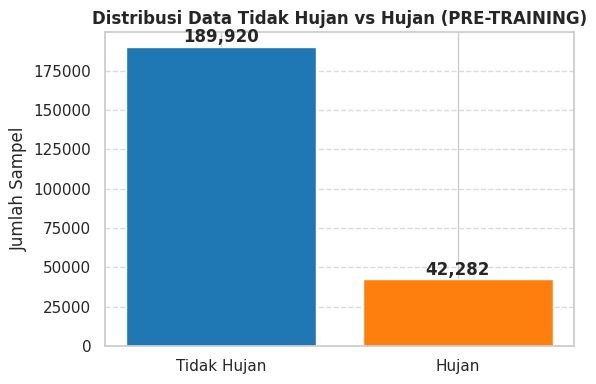

In [5]:
# Visualisasi Distribusi Hujan vs Tidak Hujan (PRE-TRAINING)
import matplotlib.pyplot as plt
import seaborn as sns

rain_count = (df_hourly['rainrate'] > 0).sum()
no_rain_count = (df_hourly['rainrate'] == 0).sum()

plt.figure(figsize=(6, 4))
bars = plt.bar(['Tidak Hujan', 'Hujan'], [no_rain_count, rain_count], color=['#1f77b4', '#ff7f0e'])
plt.title('Distribusi Data Tidak Hujan vs Hujan (PRE-TRAINING)', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Sampel')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (yval * 0.005), f'{yval:,}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Tahap 4: Rekayasa Fitur (*Feature Engineering*)

Sel ini meramu data mentah 1-jaman menjadi format 1-jaman yang siap ditelan model. Fitur-fitur canggih seperti **Tren 1 Jam** (*difference*) dihitung di sini, beserta nilai agregasi fitur konvektif tingkat lanjut (CAPE, K-Index) dari ERA5.

In [6]:
# Sel 5: Rekayasa Fitur Fisika Atmosfer
def engineer_features(df_base):
    logger.info("Mengekstraksi fitur fisika & temporal...")
    
    cols_diff = ['temperature', 'dewpoint', 'pressure']
    for c in cols_diff:
        if c in df_base.columns:
            df_base[f'{c}_tendency_1h'] = df_base[c].diff()
        
    if 'temperature' in df_base.columns and 'dewpoint' in df_base.columns:
        df_base['dewpoint_depression'] = df_base['temperature'] - df_base['dewpoint']
        
    df_base['sin_hour'] = np.sin(2 * np.pi * df_base.index.hour / 24.0)
    df_base['cos_hour'] = np.cos(2 * np.pi * df_base.index.hour / 24.0)
    df_base['sin_month'] = np.sin(2 * np.pi * df_base.index.month / 12.0)
    df_base['cos_month'] = np.cos(2 * np.pi * df_base.index.month / 12.0)
    df_base['sin_doy'] = np.sin(2 * np.pi * df_base.index.dayofyear / 365.25)
    df_base['cos_doy'] = np.cos(2 * np.pi * df_base.index.dayofyear / 365.25)

    lag_vars = ['rainrate', 'temperature', 'humidity', 'pressure', 'era5_cape']
    lags = [1, 3, 6, 12, 24]
    for var in lag_vars:
        if var in df_base.columns:
            for lag in lags:
                df_base[f'{var}_lag_{lag}h'] = df_base[var].shift(lag)

    df = df_base.copy()
    df = df.dropna()
    logger.info(f"Dimensi akhir setelah rekayasa fitur: {df.shape}")
    return df


## Tahap 5: Pelatihan Klasifikasi Hujan (Optuna)

Di sini model dilatih untuk mengenali apakah curah hujan akan mencapai ambang batas atau tidak. Sistem menggunakan algoritma pencarian cerdas **Optuna** untuk mencari kombinasi parameter terbaik.

In [7]:
# Sel 6: Setup & XGBoost Classifier Optuna
import xgboost as xgb

logger.info(f"\n{'='*50}\nMEMULAI OPTIMASI XGBOOST 3-JAM\n{'='*50}")
evaluator = ModelEvaluator()

# 1. Feature Engineering
df_features = engineer_features(df_hourly)

# 2. Target Creation (Prediksi 3 jam ke depan)
df_features['target_amount'] = df_features['rainrate'].shift(-1)
df_features = df_features.dropna()
df_features['target_occurrence'] = (df_features['target_amount'] >= RAIN_THRESHOLD).astype(int)

# 3. Data Split
# 1. Tentukan rentang data
if RUN_MODE == "PIPELINE_TEST":
    # Logika posisi untuk pengujian cepat
    n = len(df_features)
    train_mask = np.arange(n) < int(n * 0.7)
    val_mask = (np.arange(n) >= int(n * 0.7)) & (np.arange(n) < int(n * 0.9))
    test_mask = np.arange(n) >= int(n * 0.9)
else:
    # 2. Logika Tanggal Otomatis (Menggunakan fungsi get_masks dari Sel 2)
    # Kita panggil fungsi untuk mendapatkan mask secara otomatis
    train_mask = (df_features.index >= PRETRAIN__TRAIN_START) & (df_features.index <= PRETRAIN__TRAIN_END)
    val_mask = (df_features.index >= PRETRAIN__VAL_START) & (df_features.index < PRETRAIN__VAL_END)
    test_mask = (df_features.index >= PRETRAIN__TEST_START) & (df_features.index <= PRETRAIN__TEST_END)

X = df_features.drop(columns=['target_amount', 'target_occurrence'])
y_occ = df_features['target_occurrence']
y_reg = df_features['target_amount']

# Sel 6 (Bagian Data Split) - Otomatis
X_train, y_train_occ, y_train_reg = X[train_mask], y_occ[train_mask], y_reg[train_mask]
X_val, y_val_occ, y_val_reg = X[val_mask], y_occ[val_mask], y_reg[val_mask]
X_test, y_test_occ, y_test_reg = X[test_mask], y_occ[test_mask], y_reg[test_mask]

logger.info(f"Otomatisasi Split Berhasil. Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

logger.info(f"Distribusi Split - Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# Deteksi device GPU untuk Kaggle/Lokal
device_xgb = 'cuda' if os.path.exists('/kaggle/input') else 'cpu'
logger.info(f"XGBoost device yang digunakan: {device_xgb}")

# --- STAGE 1: CLASSIFIER OPTIMIZATION ---
def objective_occ(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 50, 1000),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 10, 50),
        'random_state': SEED,
        'tree_method': 'hist',
        'device': device_xgb,
        'early_stopping_rounds': 50
    }
    clf = xgb.XGBClassifier(**params)
    clf.fit(X_train, y_train_occ, eval_set=[(X_val, y_val_occ)], verbose=False)
    val_prob = clf.predict_proba(X_val)[:, 1]
    return brier_score_loss(y_val_occ, val_prob)

optuna.logging.set_verbosity(optuna.logging.INFO)
study_occ = optuna.create_study(direction='minimize')
study_occ.optimize(objective_occ, n_trials=OPTUNA_TRIALS)

# Melatih Classifier Terbaik
best_params_occ = study_occ.best_params
best_params_occ.update({
    'random_state': SEED,
    'tree_method': 'hist',
    'device': device_xgb,
    'early_stopping_rounds': 50
})
clf_best = xgb.XGBClassifier(**best_params_occ)
clf_best.fit(X_train, y_train_occ, eval_set=[(X_val, y_val_occ)], verbose=False)

# Evaluasi Kurva Loss Classifier
results_clf = clf_best.evals_result()
plt.figure(figsize=(6,4))
plt.plot(results_clf['validation_0']['logloss'], label='Validation')
plt.title('Training and Validation Logloss')
plt.ylabel('Logloss')
plt.xlabel('Trees')
plt.legend()
plt.savefig(evaluator.dirs['plots'] / 'validation_logloss.png')
plt.close()

# Plot Optimization History Optuna
try:
    fig = optuna.visualization.plot_optimization_history(study_occ)
    fig.write_image(str(evaluator.dirs['plots'] / 'optimization_history.png'))
except:
    logger.info("Plotly/Kaleido tidak tersedia, melewatkan optimization_history grafis optuna.")

joblib.dump(clf_best, evaluator.dirs['models_clf'] / 'best_xgb_occ.pkl')

# Memilih Kalibrator Terbaik Secara Dinamis Menggunakan Data Validasi
calibrator_best, calibrator_type = fit_best_calibrator(y_val_occ.values, clf_best.predict_proba(X_val)[:, 1])
joblib.dump((calibrator_best, calibrator_type), evaluator.dirs['models_cal'] / 'best_calibrator_pretrain.pkl')


2026-07-07 16:23:25,759 - INFO - 
MEMULAI OPTIMASI XGBOOST 3-JAM
2026-07-07 16:23:25,762 - INFO - Mengekstraksi fitur fisika & temporal...
2026-07-07 16:23:26,068 - INFO - Dimensi akhir setelah rekayasa fitur: (232178, 46)
2026-07-07 16:23:26,187 - INFO - Otomatisasi Split Berhasil. Train: 140233, Val: 26256, Test: 17521
2026-07-07 16:23:26,188 - INFO - Distribusi Split - Train: 140233, Val: 26256, Test: 17521
2026-07-07 16:23:26,190 - INFO - XGBoost device yang digunakan: cuda
[I 2026-07-07 16:23:26,191] A new study created in memory with name: no-name-8adc116e-e2d7-4c27-a448-f3e91814bdfb
[I 2026-07-07 16:23:27,902] Trial 0 finished with value: 0.07112643251091744 and parameters: {'max_depth': 5, 'learning_rate': 0.07542502853715469, 'n_estimators': 55, 'subsample': 0.9707125870385146, 'colsample_bytree': 0.7002372337326866, 'gamma': 4.380583117301701, 'min_child_weight': 39}. Best is trial 0 with value: 0.07112643251091744.
[I 2026-07-07 16:23:34,258] Trial 1 finished with value: 0.0

['outputs_xgboost/models/calibration/best_calibrator_pretrain.pkl']

## Tahap 6: Pelatihan Regresi Intensitas (Optuna)

Setelah model tahu bahwa akan turun hujan, model *Regressor* ini bertugas menebak **Berapa lebat hujannya?** (dalam satuan milimeter). Hanya wilayah dengan probabilitas hujan tinggi yang dilatih di tahap ini.

In [8]:
# Sel 7: XGBoost Regressor Optuna
# --- STAGE 2: REGRESSOR OPTIMIZATION ---
rainy_mask_train = y_train_occ == 1
rainy_mask_val = y_val_occ == 1
X_train_r, y_train_r = X_train[rainy_mask_train], y_train_reg[rainy_mask_train]
X_val_r, y_val_r = X_val[rainy_mask_val], y_val_reg[rainy_mask_val]

device_xgb = 'cuda' if os.path.exists('/kaggle/input') else 'cpu'

if np.sum(rainy_mask_train) > 10:
    def objective_reg(trial):
        params = {
            'objective': 'reg:squarederror', # Menggunakan MSE agar model dihukum berat jika gagal menebak hujan lebat
            'eval_metric': 'rmse',
            'max_depth': trial.suggest_int('max_depth', 8, 12),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
            'n_estimators': trial.suggest_int('n_estimators', 50, 1000),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 10, 50),
            'random_state': SEED, 
            'tree_method': 'hist', 
            'device': device_xgb,
            'early_stopping_rounds': 50
        }
        reg = xgb.XGBRegressor(**params)
        reg.fit(X_train_r, y_train_r, eval_set=[(X_val_r, y_val_r)], verbose=False)
        preds = reg.predict(X_val_r)
        return mean_squared_error(y_val_r, preds)
        
    study_reg = optuna.create_study(direction='minimize')
    study_reg.optimize(objective_reg, n_trials=OPTUNA_TRIALS)
    
    best_params_reg = study_reg.best_params
    best_params_reg.update({
        'random_state': SEED,
        'tree_method': 'hist',
        'device': device_xgb,
        'early_stopping_rounds': 50
    })
    reg_best = xgb.XGBRegressor(**best_params_reg)
    reg_best.fit(X_train_r, y_train_r, eval_set=[(X_train_r, y_train_r), (X_val_r, y_val_r)], verbose=False)
    joblib.dump(reg_best, evaluator.dirs['models_reg'] / 'best_xgb_reg.pkl')
    
    # RMSE Curves
    results_reg = reg_best.evals_result()
    plt.figure(figsize=(6,4))
    plt.plot(results_reg['validation_0']['rmse'], label='Train RMSE')
    plt.plot(results_reg['validation_1']['rmse'], label='Val RMSE')
    plt.title('Training and Validation RMSE')
    plt.legend()
    plt.savefig(evaluator.dirs['plots'] / 'regressor_learning_curve.png')
    plt.close()
else:
    logger.warning("Tidak cukup sampel hujan untuk melatih Regressor.")
    reg_best = None


[I 2026-07-07 16:29:28,194] A new study created in memory with name: no-name-1446f196-817b-4249-8c5a-d7440e58ea6a
[I 2026-07-07 16:29:36,891] Trial 0 finished with value: 11.734078772062743 and parameters: {'max_depth': 11, 'learning_rate': 0.012824520029288935, 'n_estimators': 608, 'subsample': 0.6721632483182965, 'colsample_bytree': 0.6217586306753922, 'gamma': 1.9736849414747688, 'min_child_weight': 26}. Best is trial 0 with value: 11.734078772062743.
[I 2026-07-07 16:29:42,195] Trial 1 finished with value: 15.009665978476379 and parameters: {'max_depth': 9, 'learning_rate': 0.003086812523244928, 'n_estimators': 181, 'subsample': 0.7735522666075692, 'colsample_bytree': 0.6503848006951373, 'gamma': 4.309756810144726, 'min_child_weight': 22}. Best is trial 0 with value: 11.734078772062743.
[I 2026-07-07 16:30:03,302] Trial 2 finished with value: 13.657423963918296 and parameters: {'max_depth': 12, 'learning_rate': 0.0028788148697882787, 'n_estimators': 243, 'subsample': 0.945553644730

## FASE 2: FINE-TUNING (Data Aktual Stasiun AWS)

**Tujuan:** Menyelaraskan model dengan kondisi iklim lokal.
Sel ini menukar sumber data dasar menjadi **data pengukuran asli dari Stasiun AWS**, sembari mempertahankan fitur Angin dan Konvektif yang dipinjam secara dinamis dari ERA5.

In [9]:
# --- FASE FINE-TUNING ---
# Sel 12: Pemuatan Data dan Penyatuan (Data Loading & Merge) untuk FINE-TUNING
import os
from pathlib import Path
import pandas as pd
import numpy as np

logger.info("Mendeteksi Environment & Memuat data stasional untuk Fine-Tuning...")

if os.path.exists('/kaggle/input'):
    import glob
    search_file = glob.glob('/kaggle/input/**/id-05_clear_data_hourly.csv', recursive=True)
    if search_file:
        STATION_FILE = Path(search_file[0])
        sat_search = glob.glob('/kaggle/input/**/ERA5_Hourly_All_Requested_Features_2000_2026.csv', recursive=True)
        if sat_search:
            SAT_DIR = Path(sat_search[0]).parent
        else:
            SAT_DIR = Path('/kaggle/input/google-earth-engine-data/Google_Earth_Engine/Data_Satelit')
    else:
        STATION_FILE = Path('/kaggle/input/google-earth-engine-data/Google_Earth_Engine/Data_Stasiun/id-05_clear_data_hourly.csv')
        SAT_DIR = Path('/kaggle/input/google-earth-engine-data/Google_Earth_Engine/Data_Satelit')
else:
    BASE_DATA_DIR = Path('D:/Github/Projek_Rainfall')
    STATION_FILE = BASE_DATA_DIR / 'Google_Earth_Engine' / 'Data_Satelit' / 'id-05_clear_data_hourly.csv'
    SAT_DIR = BASE_DATA_DIR / 'Google_Earth_Engine' / 'Data_Satelit'

# 1. Memuat Data Stasiun AWS Lokal
df_station = pd.read_csv(STATION_FILE)
df_station['timestamp'] = pd.to_datetime(df_station['datetime_utc'], utc=True)
df_station = df_station.set_index('timestamp').sort_index()
# Hanya ambil kolom yang relevan dari AWS
cols_to_keep = ['temperature', 'humidity', 'pressure', 'dewpoint', 'rainrate']
df_station = df_station[cols_to_keep]

# 2. Memuat ERA5
df_era5 = pd.read_csv(SAT_DIR / 'ERA5_Hourly_All_Requested_Features_2000_2026.csv')
if 'datetime_utc' in df_era5.columns:
    df_era5['timestamp'] = pd.to_datetime(df_era5['datetime_utc'], utc=True)
else:
    df_era5['timestamp'] = pd.to_datetime(df_era5['unixtime'], unit='s', utc=True)
df_era5 = df_era5.set_index('timestamp').sort_index()

df_merged = df_era5.copy()

# Pemetaan Variabel menggunakan Konfigurasi Global
for raw_col, new_name in ERA5_FEATURES_MAPPING.items():
    if raw_col in df_era5.columns:
        df_merged[new_name] = df_era5[raw_col]

# Hapus noise drizzle efek ERA5 (WMO wet-day threshold 0.1 mm/h)
if 'rainrate' in df_merged.columns:
    df_merged['rainrate'] = np.where(df_merged['rainrate'] >= 0.1, df_merged['rainrate'], 0.0)

# Simpan hanya fitur yang dipetakan
selected_features = list(ERA5_FEATURES_MAPPING.values())
df_merged = df_merged[[c for c in selected_features if c in df_merged.columns]]

# [REPLACEMENT AWS]
# Gabungkan dengan AWS. Di mana AWS ada, timpa ERA5!
df_merged.update(df_station)

# Potong dataset mulai 2025 (AWS hanya ada 2025-2026)
df_merged = df_merged[df_merged.index >= '2024-12-01']

drop_subset = ['temperature'] if 'temperature' in df_merged.columns else None
df_hourly = df_merged.dropna(subset=drop_subset).copy() if drop_subset else df_merged.dropna().copy()
df_hourly = df_hourly.select_dtypes(include=[np.number])
logger.info(f"Dimensi data terpadu (FINE-TUNING): {df_hourly.shape}")


2026-07-07 16:33:42,839 - INFO - Mendeteksi Environment & Memuat data stasional untuk Fine-Tuning...
2026-07-07 16:33:44,850 - INFO - Dimensi data terpadu (FINE-TUNING): (13778, 11)


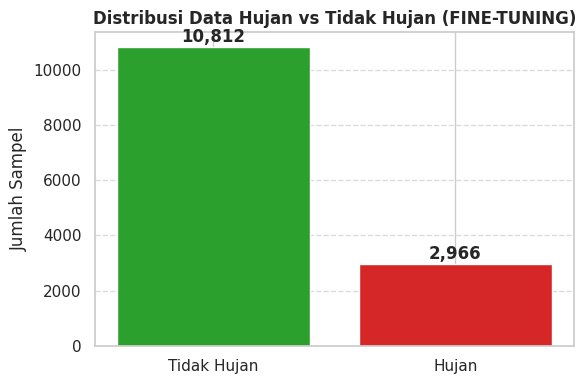

In [10]:
# Visualisasi Distribusi Hujan vs Tidak Hujan (FINE-TUNING)
import matplotlib.pyplot as plt
import seaborn as sns

rain_count = (df_hourly['rainrate'] > 0).sum()
no_rain_count = (df_hourly['rainrate'] == 0).sum()

plt.figure(figsize=(6, 4))
bars = plt.bar(['Tidak Hujan', 'Hujan'], [no_rain_count, rain_count], color=['#2ca02c', '#d62728'])
plt.title('Distribusi Data Hujan vs Tidak Hujan (FINE-TUNING)', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Sampel')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (yval * 0.005), f'{yval:,}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Inspeksi Data Fine-Tuning

Menampilkan struktur data, jumlah kolom, dan kelengkapan (*missing values*) dari data terpadu AWS sebelum masuk ke tahap *Feature Engineering*.

In [11]:
df_hourly.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13778 entries, 2024-12-01 00:00:00+00:00 to 2026-06-28 05:00:00+00:00
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   temperature       13778 non-null  float64
 1   humidity          13778 non-null  float64
 2   dewpoint          13778 non-null  float64
 3   rainrate          13778 non-null  float64
 4   pressure          13778 non-null  float64
 5   era5_u_wind       13778 non-null  float64
 6   era5_v_wind       13778 non-null  float64
 7   era5_cloud_cover  13778 non-null  float64
 8   era5_cape         13778 non-null  float64
 9   era5_tcwv         13778 non-null  float64
 10  era5_sunshine     13778 non-null  float64
dtypes: float64(11)
memory usage: 1.3 MB


In [12]:
df_features.head(10)

,temperature,humidity,dewpoint,rainrate,pressure,era5_u_wind,era5_v_wind,era5_cloud_cover,era5_cape,era5_tcwv,...,pressure_lag_6h,pressure_lag_12h,pressure_lag_24h,era5_cape_lag_1h,era5_cape_lag_3h,era5_cape_lag_6h,era5_cape_lag_12h,era5_cape_lag_24h,target_amount,target_occurrence
timestamp,,,,,,,,,,,,,,,,,,,,,
2000-01-02 00:00:00+00:00,27.417963,86.283854,24.921991,0.000000,1007.205469,0.066127,-0.158881,0.981444,758.247192,56.471428,...,1006.885391,1006.800078,1007.738047,340.717285,274.498535,225.414795,745.500000,332.713867,0.000000,0
2000-01-02 01:00:00+00:00,28.041772,79.139811,24.086816,0.000000,1007.907109,0.218242,-0.173999,0.980773,360.365356,56.744328,...,1006.060469,1007.745000,1008.240781,758.247192,215.490479,189.473389,573.395752,228.722046,0.000000,0
2000-01-02 02:00:00+00:00,29.282220,74.666781,24.316858,0.000000,1007.746719,0.299277,0.190473,0.971373,559.132812,56.428085,...,1005.766094,1008.472656,1008.312812,360.365356,340.717285,236.030273,552.891724,402.979980,0.390000,1
2000-01-02 03:00:00+00:00,30.333063,70.483760,24.363794,0.390000,1007.223047,0.089018,0.811132,0.965636,754.993896,56.026310,...,1005.646406,1008.430313,1007.645469,559.132812,758.247192,274.498535,443.091675,700.160034,2.630000,1
2000-01-02 04:00:00+00:00,30.827753,68.533312,24.367822,2.630000,1006.828828,0.307084,1.171229,0.934537,910.800049,56.632156,...,1005.063906,1008.277500,1007.054062,754.993896,360.365356,215.490479,413.512695,1086.020752,3.170000,1
2000-01-02 05:00:00+00:00,30.861383,70.328000,24.832208,3.170000,1006.006172,1.352881,2.045646,0.973662,1175.275635,56.955036,...,1006.286172,1007.652344,1006.341250,910.800049,559.132812,340.717285,349.666748,1398.616699,9.700000,1
2000-01-02 06:00:00+00:00,31.263910,68.590261,24.797540,9.700000,1005.355391,1.151146,2.147299,0.998474,1306.541748,57.709724,...,1007.205469,1006.885391,1005.788516,1175.275635,754.993896,758.247192,225.414795,1459.747681,21.380000,1
2000-01-02 07:00:00+00:00,31.091699,69.580485,24.873315,21.380000,1004.990781,-0.841326,1.006191,1.000000,1533.674805,58.367531,...,1007.907109,1006.060469,1004.600000,1306.541748,910.800049,360.365356,189.473389,1378.146851,15.720000,1
2000-01-02 08:00:00+00:00,30.980402,69.461924,24.738458,15.720000,1005.123594,-0.403464,0.159741,1.000000,1757.741943,59.688576,...,1007.746719,1005.766094,1003.984844,1533.674805,1175.275635,559.132812,236.030273,1195.489868,52.799999,1


## Tahap 4: Rekayasa Fitur (*Feature Engineering*)

In [13]:
# Sel 5: Rekayasa Fitur Fisika Atmosfer (Fine-Tuning)
def engineer_features(df_base):
    logger.info("Mengekstraksi fitur fisika & temporal...")
    
    cols_diff = ['temperature', 'dewpoint', 'pressure']
    for c in cols_diff:
        if c in df_base.columns:
            df_base[f'{c}_tendency_1h'] = df_base[c].diff()
        
    if 'temperature' in df_base.columns and 'dewpoint' in df_base.columns:
        df_base['dewpoint_depression'] = df_base['temperature'] - df_base['dewpoint']
        
    df_base['sin_hour'] = np.sin(2 * np.pi * df_base.index.hour / 24.0)
    df_base['cos_hour'] = np.cos(2 * np.pi * df_base.index.hour / 24.0)
    df_base['sin_month'] = np.sin(2 * np.pi * df_base.index.month / 12.0)
    df_base['cos_month'] = np.cos(2 * np.pi * df_base.index.month / 12.0)
    df_base['sin_doy'] = np.sin(2 * np.pi * df_base.index.dayofyear / 365.25)
    df_base['cos_doy'] = np.cos(2 * np.pi * df_base.index.dayofyear / 365.25)

    # Menambahkan fitur lag (1, 3, 6, 12, 24 jam) untuk 5 variabel meteorologi utama
    lag_vars = ['rainrate', 'temperature', 'humidity', 'pressure', 'era5_cape']
    lags = [1, 3, 6, 12, 24]
    for var in lag_vars:
        if var in df_base.columns:
            for lag in lags:
                df_base[f'{var}_lag_{lag}h'] = df_base[var].shift(lag)

    df = df_base.copy()
    df = df.dropna()
    logger.info(f"Dimensi akhir setelah rekayasa fitur: {df.shape}")
    return df


In [14]:
# Ekstraksi Fitur dan Pembuatan Target untuk Fine-Tuning
df_features = engineer_features(df_hourly)

# Target Creation (Prediksi 3 jam ke depan, persis seperti pre-training)
df_features['target_amount'] = df_features['rainrate'].shift(-1)
df_features = df_features.dropna()
df_features['target_occurrence'] = (df_features['target_amount'] >= RAIN_THRESHOLD).astype(int)

# [PEMBAGIAN DATA FINE-TUNING BERDASARKAN TANGGAL]
if RUN_MODE == "PIPELINE_TEST":
    n = len(df_features)
    train_mask = np.arange(n) < int(n * 0.6)
    val_mask = (np.arange(n) >= int(n * 0.6)) & (np.arange(n) < int(n * 0.8))
    test_mask = np.arange(n) >= int(n * 0.8)
else:
    train_mask = (df_features.index >= FINETUNE_TRAIN_START) & (df_features.index <= FINETUNE_TRAIN_END)
    val_mask = (df_features.index >= FINETUNE_VAL_START) & (df_features.index < FINETUNE_VAL_END)
    test_mask = (df_features.index >= FINETUNE_TEST_START) & (df_features.index <= FINETUNE_TEST_END)

X = df_features.drop(columns=['target_amount', 'target_occurrence'])
y_occ = df_features['target_occurrence']
y_reg = df_features['target_amount']

X_train, y_train_occ, y_train_reg = X[train_mask], y_occ[train_mask], y_reg[train_mask]
X_val, y_val_occ, y_val_reg = X[val_mask], y_occ[val_mask], y_reg[val_mask]
X_test, y_test_occ, y_test_reg = X[test_mask], y_occ[test_mask], y_reg[test_mask]

logger.info(f"Dimensi X_train (Fine-Tuning): {X_train.shape}")
logger.info(f"Dimensi X_val (Fine-Tuning): {X_val.shape}")
logger.info(f"Dimensi X_test (Fine-Tuning): {X_test.shape}")


2026-07-07 16:33:45,220 - INFO - Mengekstraksi fitur fisika & temporal...
2026-07-07 16:33:45,248 - INFO - Dimensi akhir setelah rekayasa fitur: (13754, 46)
2026-07-07 16:33:45,260 - INFO - Dimensi X_train (Fine-Tuning): (9097, 46)
2026-07-07 16:33:45,261 - INFO - Dimensi X_val (Fine-Tuning): (1896, 46)
2026-07-07 16:33:45,262 - INFO - Dimensi X_test (Fine-Tuning): (1321, 46)


## Tahap Terakhir: Proses Fine-Tuning & Perbandingan Model

Di tahap ini, model yang sudah pintar secara global di-*retrain* menggunakan dataset lokal (AWS). Sel ini juga mengaplikasikan **Isotonic Regression** untuk kalibrasi probabilitas, lalu menghasilkan laporan komparasi performa *Pre-trained* vs *Fine-tuned*.

2026-07-07 16:33:45,333 - INFO - Mengevaluasi Model Pre-Trained XGBoost pada Data Test AWS...


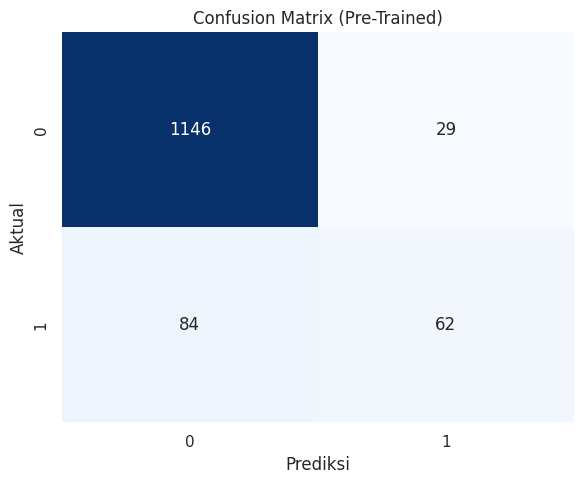

2026-07-07 16:33:45,514 - INFO - Memulai Fine-Tuning XGBoost Classifier...
2026-07-07 16:33:46,117 - INFO - [Calibrator Selection] Brier scores - Raw: 0.1999, Platt: 0.1888, Isotonic: 0.1846
2026-07-07 16:33:46,118 - INFO - [Calibrator Selection] Selected Isotonic Calibrator
2026-07-07 16:33:46,120 - INFO - Memulai Fine-Tuning XGBoost Regressor...
2026-07-07 16:33:47,570 - INFO - Menghitung metrik klasifikasi...


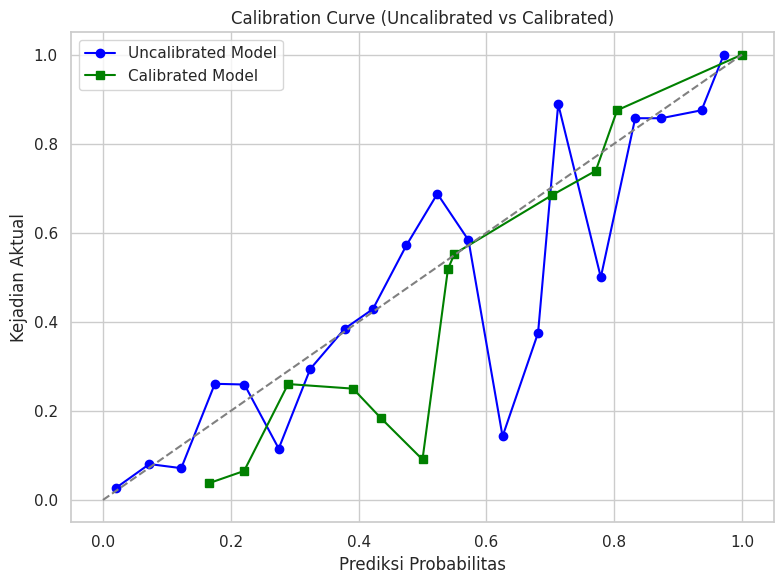

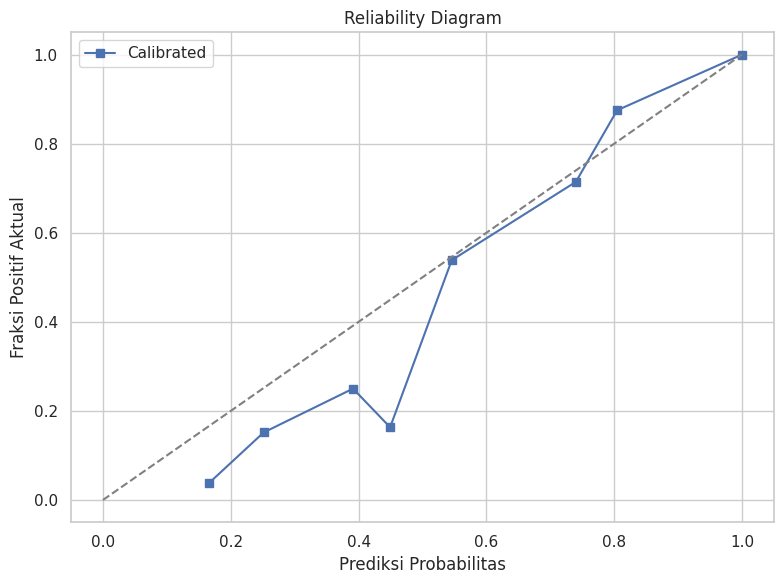

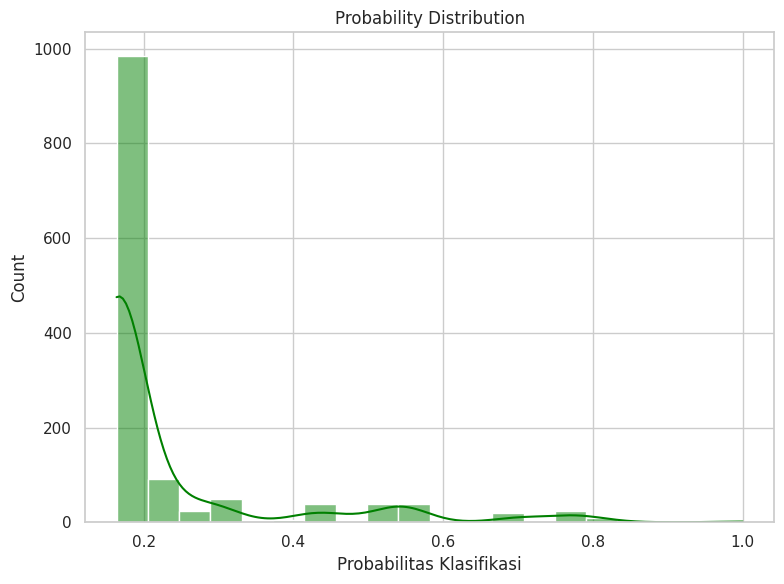

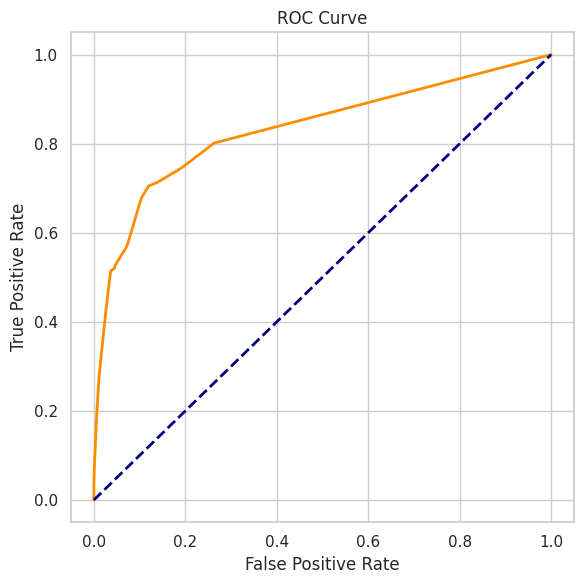

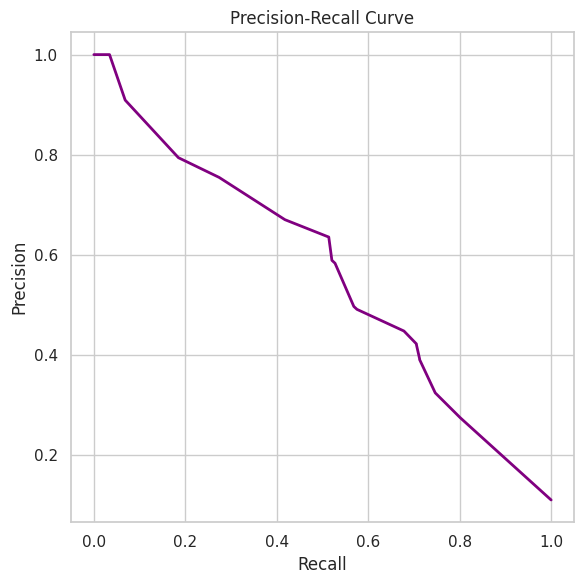

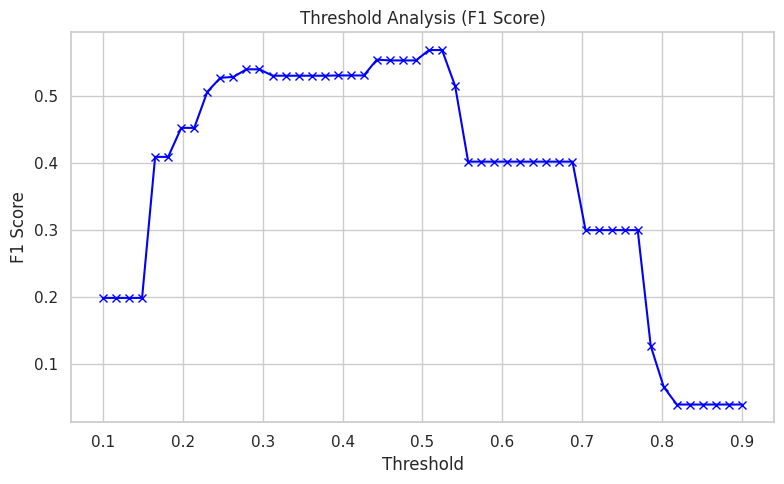

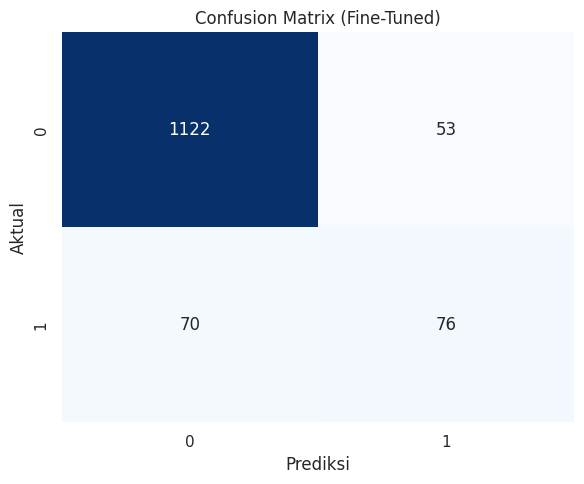

2026-07-07 16:33:49,640 - INFO - Menghitung metrik regresi...


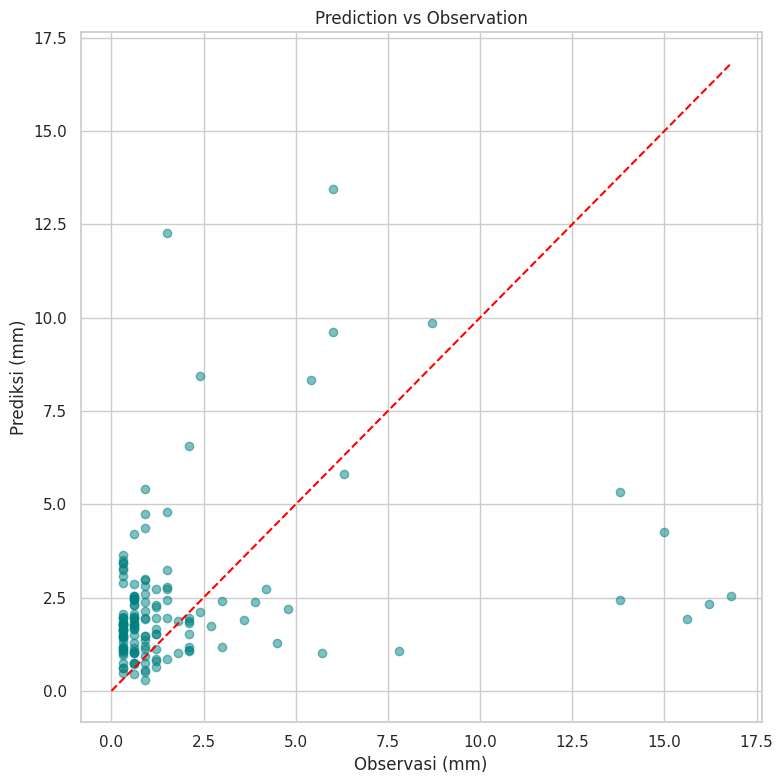

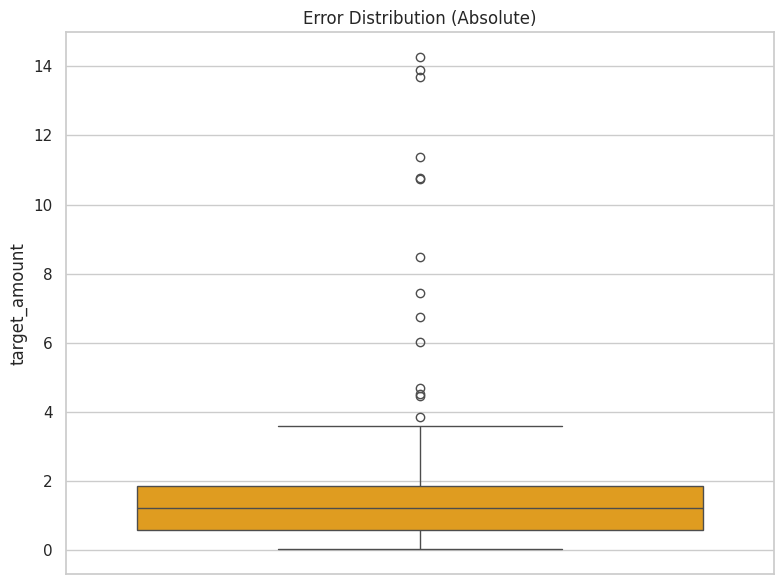

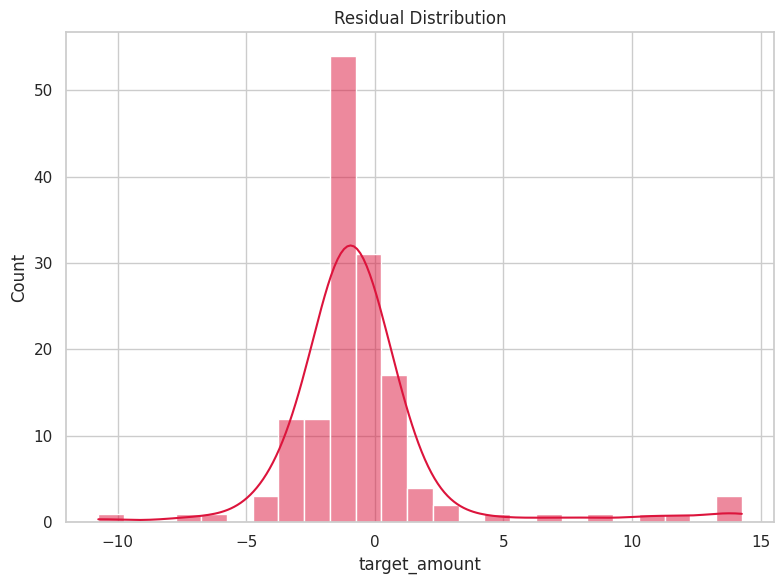

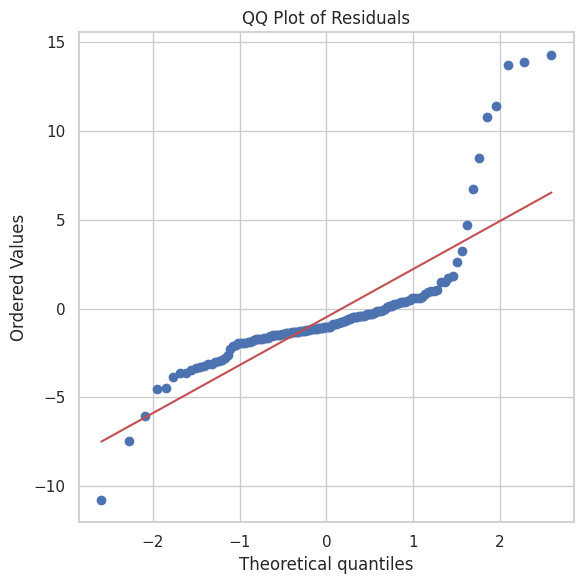

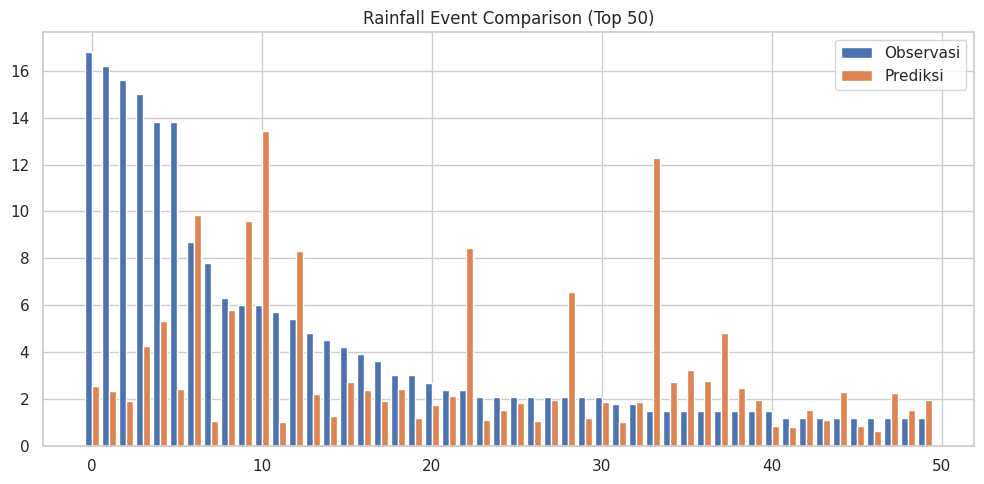

2026-07-07 16:33:51,393 - INFO - Membuat Plot Perbandingan Pre-Trained vs Fine-Tuned (XGBoost)...


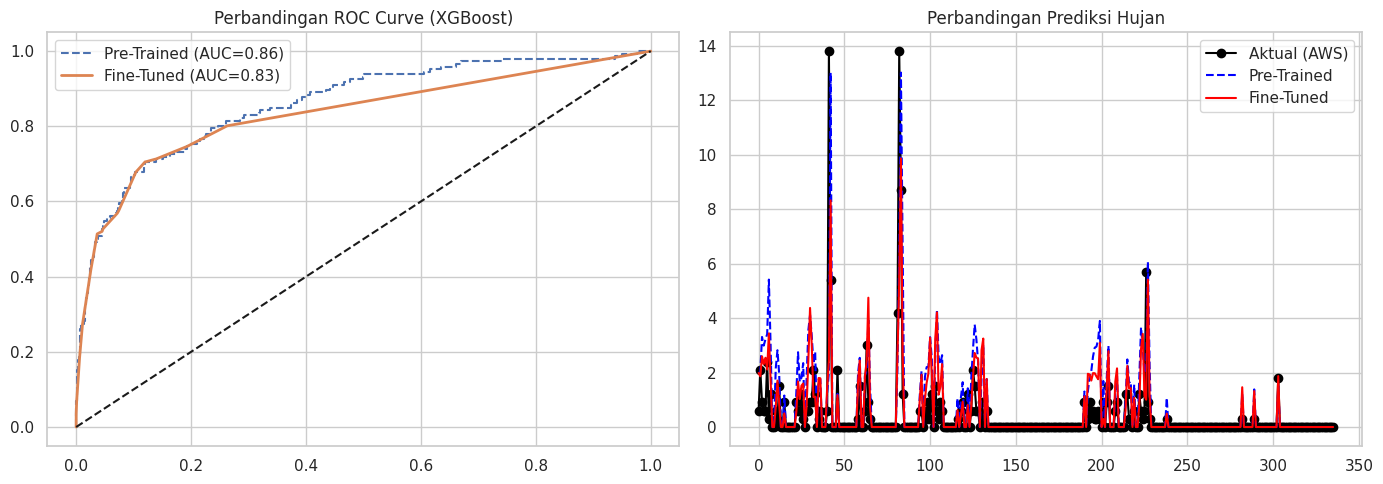

2026-07-07 16:33:52,030 - INFO - Unified XGBoost Pipeline Selesai!


In [15]:
# Sel 10: Proses Fine-Tuning & Perbandingan Model (XGBoost)
import xgboost as xgb
import joblib
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Penyelarasan Urutan Fitur (Feature Alignment)
if hasattr(clf_best, 'feature_names_in_'):
    feature_order = clf_best.feature_names_in_
elif hasattr(clf_best, 'feature_names') and clf_best.feature_names is not None:
    feature_order = clf_best.feature_names
else:
    feature_order = clf_best.get_booster().feature_names

X_train = X_train[feature_order]
X_val = X_val[feature_order]
X_test = X_test[feature_order]
X = X[feature_order]

device_xgb = 'cuda' if os.path.exists('/kaggle/input') else 'cpu'

# 1. EVALUASI BEFORE TUNING (Pre-trained Model)
logger.info("Mengevaluasi Model Pre-Trained XGBoost pada Data Test AWS...")
pre_test_probs = clf_best.predict_proba(X_test)[:, 1]
calibrator_pre, calibrator_type_pre = joblib.load(evaluator.dirs['models_cal'] / 'best_calibrator_pretrain.pkl')
pre_test_probs_cal = apply_calibrator(calibrator_pre, calibrator_type_pre, pre_test_probs)
pre_test_preds = (pre_test_probs_cal >= 0.5).astype(int)

pre_test_preds_r = np.zeros(len(y_test_occ))
rainy_te = y_test_occ == 1
if reg_best is not None and np.sum(rainy_te) > 0:
    pre_test_preds_r[rainy_te] = reg_best.predict(X_test[rainy_te])

evaluator.plot_confusion_matrix(y_test_occ, pre_test_preds, suffix='(Pre-Trained)')

# 2. PROSES FINE-TUNING (Warm-Start / Update dengan Data AWS)
logger.info("Memulai Fine-Tuning XGBoost Classifier...")
clf_best.set_params(learning_rate=0.01, device=device_xgb)
clf_best.fit(X_train, y_train_occ, eval_set=[(X_val, y_val_occ)], xgb_model=clf_best.get_booster(), verbose=False)
joblib.dump(clf_best, evaluator.dirs['models_clf'] / 'best_xgb_occ_finetuned.pkl')

# Calibrator Re-fit menggunakan data validasi fine-tuning
val_probs_uncal = clf_best.predict_proba(X_val)[:, 1]
calibrator_post, calibrator_type_post = fit_best_calibrator(y_val_occ.values, val_probs_uncal)
joblib.dump((calibrator_post, calibrator_type_post), evaluator.dirs['models_cal'] / 'best_calibrator_finetuned.pkl')

if reg_best is not None and np.sum(y_train_occ == 1) > 10:
    logger.info("Memulai Fine-Tuning XGBoost Regressor...")
    reg_best.set_params(learning_rate=0.01, device=device_xgb)
    rainy_mask_tr = y_train_occ == 1
    rainy_mask_va = y_val_occ == 1
    reg_best.fit(X_train[rainy_mask_tr], y_train_reg[rainy_mask_tr], 
                 eval_set=[(X_val[rainy_mask_va], y_val_reg[rainy_mask_va])], 
                 xgb_model=reg_best.get_booster(), verbose=False)
    joblib.dump(reg_best, evaluator.dirs['models_reg'] / 'best_xgb_reg_finetuned.pkl')

# 3. EVALUASI AFTER TUNING
test_probs_uncal = clf_best.predict_proba(X_test)[:, 1]
test_probs_cal = apply_calibrator(calibrator_post, calibrator_type_post, test_probs_uncal)
test_preds_occ = (test_probs_cal >= 0.5).astype(int)

clf_metrics, meteo_metrics = evaluator.evaluate_classification(y_test_occ, test_probs_uncal, test_probs_cal, test_preds_occ)
evaluator.plot_confusion_matrix(y_test_occ, test_preds_occ, suffix='(Fine-Tuned)')

test_preds_r = np.zeros(len(y_test_occ))
reg_metrics = {}
if reg_best is not None and np.sum(rainy_te) > 0:
    test_preds_r[rainy_te] = reg_best.predict(X_test[rainy_te])
    reg_metrics = evaluator.evaluate_regression(y_test_reg[rainy_te], test_preds_r[rainy_te])

# 4. PLOTTING PERBANDINGAN (Before vs After)
logger.info("Membuat Plot Perbandingan Pre-Trained vs Fine-Tuned (XGBoost)...")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Classification ROC Before vs After
fpr_pre, tpr_pre, _ = roc_curve(y_test_occ, pre_test_probs)
fpr_post, tpr_post, _ = roc_curve(y_test_occ, test_probs_cal)

ax[0].plot(fpr_pre, tpr_pre, label=f'Pre-Trained (AUC={auc(fpr_pre, tpr_pre):.2f})', linestyle='--')
ax[0].plot(fpr_post, tpr_post, label=f'Fine-Tuned (AUC={auc(fpr_post, tpr_post):.2f})', linewidth=2)
ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_title('Perbandingan ROC Curve (XGBoost)')
ax[0].legend()

# Timeseries Before vs After
start_idx = 0
end_idx = min(336, len(y_test_reg))

ax[1].plot(y_test_reg.values[start_idx:end_idx], label='Aktual (AWS)', color='black', marker='o')
ax[1].plot(pre_test_preds_r[start_idx:end_idx], label='Pre-Trained', color='blue', linestyle='--')
ax[1].plot(test_preds_r[start_idx:end_idx], label='Fine-Tuned', color='red', linestyle='-')
ax[1].set_title('Perbandingan Prediksi Hujan')
ax[1].legend()

plt.tight_layout()
plt.savefig(evaluator.dirs['plots'] / 'finetuning_comparison_xgb.png')
plt.show()
plt.close()

evaluator.generate_report(len(X_train), len(X_val), len(X_test), X.columns.tolist(), clf_metrics, meteo_metrics, reg_metrics, "XGBoost (Fine-Tuned)")
logger.info("Unified XGBoost Pipeline Selesai!")


In [16]:
# Sel 6.1: Inspeksi Proporsi dan Validasi Sampel Hujan
import numpy as np

def cek_proporsi_data(X_tr, y_tr, X_va, y_va, X_te, y_te):
    print(f"=== Analisis Distribusi Sampel Data ===")
    print(f"Jumlah Latih (Train) : {len(X_tr)} baris")
    print(f"Jumlah Validasi (Val): {len(X_va)} baris")
    print(f"Jumlah Uji (Test)    : {len(X_te)} baris")
    print("-" * 45)
    
    hujan_train = np.sum(y_tr == 1)
    hujan_val = np.sum(y_va == 1)
    hujan_test = np.sum(y_te == 1)
    
    print(f"Sampel Hujan di Latih  : {hujan_train} kejadian ({hujan_train/len(y_tr)*100:.2f}%)")
    print(f"Sampel Hujan di Val    : {hujan_val} kejadian ({hujan_val/len(y_va)*100:.2f}%)")
    print(f"Sampel Hujan di Uji    : {hujan_test} kejadian ({hujan_test/len(y_te)*100:.2f}%)")
    print("=" * 45)
    
    if hujan_test < 15:
        print("Peringatan: Sampel hujan di data uji terlalu sedikit untuk evaluasi regresi yang stabil.")
    else:
        print("Status: Aman. Jumlah sampel hujan di data uji cukup untuk menguji performa intensitas.")

cek_proporsi_data(X_train, y_train_occ, X_val, y_val_occ, X_test, y_test_occ)


=== Analisis Distribusi Sampel Data ===
Jumlah Latih (Train) : 9097 baris
Jumlah Validasi (Val): 1896 baris
Jumlah Uji (Test)    : 1321 baris
---------------------------------------------
Sampel Hujan di Latih  : 1377 kejadian (15.14%)
Sampel Hujan di Val    : 656 kejadian (34.60%)
Sampel Hujan di Uji    : 146 kejadian (11.05%)
Status: Aman. Jumlah sampel hujan di data uji cukup untuk menguji performa intensitas.


## Analisis SHAP (*Feature Importance*)

Menghasilkan visualisasi *Game Theory* (SHAP) untuk membongkar kotak hitam (*blackbox*) model. Grafik ini menunjukkan **variabel mana yang paling kuat pengaruhnya** (misal: *CAPE* atau *Kelembaban*) dalam memicu prediksi hujan lebat.

In [17]:
# Sel Terpisah: Scientific Bias Correction and Calibration Module
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    brier_score_loss, roc_auc_score, f1_score, confusion_matrix,
    precision_recall_curve, auc
)
from scipy.interpolate import interp1d
import scipy.stats as stats
import joblib

class MeteorologicalBiasCorrection:
    def __init__(self, base_dir, model_name):
        self.base_dir = Path(base_dir)
        self.model_name = model_name
        self.dirs = {
            'reports': self.base_dir / 'outputs' / 'bias' / model_name / 'reports',
            'plots': self.base_dir / 'outputs' / 'bias' / model_name / 'plots',
            'calibration': self.base_dir / 'outputs' / 'bias' / model_name / 'calibration',
            'coefficients': self.base_dir / 'outputs' / 'bias' / model_name / 'coefficients',
            'metrics': self.base_dir / 'outputs' / 'bias' / model_name / 'metrics'
        }
        for d in self.dirs.values():
            d.mkdir(parents=True, exist_ok=True)
            
        self.mean_bias = 0
        self.linear_a = 1
        self.linear_b = 0
        self.qm_interp = None
        
        self.calibrator = None
        self.calibrator_type = None
        
        self.dynamic_model = None
        self.best_regression_method = "raw"
        
    def _calc_nse(self, obs, pred):
        return 1 - (np.sum((obs - pred)**2) / (np.sum((obs - np.mean(obs))**2) + 1e-9))
        
    def _calc_kge(self, obs, pred):
        if np.std(obs) == 0 or np.std(pred) == 0: return 0
        r = np.corrcoef(obs, pred)[0, 1]
        alpha = np.std(pred) / (np.std(obs) + 1e-9)
        beta = np.mean(pred) / (np.mean(obs) + 1e-9)
        return 1 - np.sqrt((r - 1)**2 + (beta - 1)**2 + (alpha - 1)**2)
        
    def _calc_classification_metrics(self, obs, pred_binary):
        cm = confusion_matrix(obs, pred_binary)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
        else:
            tn, fp, fn, tp = cm[0,0], 0, 0, 0
            if len(np.unique(obs)) > 1: tp = cm[1,1]
            
        hits = tp
        misses = fn
        false_alarms = fp
        correct_negatives = tn
        total = hits + misses + false_alarms + correct_negatives
        
        pod = hits / (hits + misses + 1e-9)
        far = false_alarms / (hits + false_alarms + 1e-9)
        csi = hits / (hits + misses + false_alarms + 1e-9)
        
        hits_random = ((hits + misses) * (hits + false_alarms)) / (total + 1e-9)
        ets = (hits - hits_random) / (hits + misses + false_alarms - hits_random + 1e-9)
        
        expected_correct = ((hits + misses)*(hits + false_alarms) + (correct_negatives + misses)*(correct_negatives + false_alarms)) / (total + 1e-9)
        hss = (hits + correct_negatives - expected_correct) / (total - expected_correct + 1e-9)
        
        return {'POD': pod, 'FAR': far, 'CSI': csi, 'ETS': ets, 'HSS': hss}

    def _calc_ece(self, obs, probs, n_bins=10):
        bin_limits = np.linspace(0, 1, n_bins + 1)
        ece = 0.0
        mce = 0.0
        for i in range(n_bins):
            mask = (probs >= bin_limits[i]) & (probs < bin_limits[i+1])
            if i == n_bins - 1:
                mask = (probs >= bin_limits[i]) & (probs <= bin_limits[i+1])
            if np.sum(mask) > 0:
                prob_pred = np.mean(probs[mask])
                prob_true = np.mean(obs[mask])
                diff = np.abs(prob_pred - prob_true)
                ece += (np.sum(mask) / len(obs)) * diff
                mce = max(mce, diff)
        return ece, mce
        
    def fit_regression(self, val_obs, val_preds):
        logger.info("[Bias Correction] Estimating Continuous Prediction Bias...")
        self.mean_bias = np.mean(val_preds - val_obs)
        
        try:
            slope, intercept = np.polyfit(val_preds, val_obs, 1)
            self.linear_a = slope
            self.linear_b = intercept
        except:
            pass
            
        sorted_preds = np.sort(val_preds)
        sorted_obs = np.sort(val_obs)
        u_preds, indices = np.unique(sorted_preds, return_index=True)
        u_obs = sorted_obs[indices]
        if len(u_preds) > 1:
            self.qm_interp = interp1d(u_preds, u_obs, bounds_error=False, fill_value=(u_obs[0], u_obs[-1]))
            
        raw_rmse = np.sqrt(mean_squared_error(val_obs, val_preds))
        qm_preds = self.qm_interp(val_preds) if self.qm_interp else val_preds
        qm_rmse = np.sqrt(mean_squared_error(val_obs, qm_preds))
        
        if qm_rmse < raw_rmse:
            self.best_regression_method = "quantile_mapping"
        else:
            self.best_regression_method = "raw"
            
        logger.info(f"[Bias Correction] Chosen Regression Correction: {self.best_regression_method}")
        
    def fit_classification(self, val_obs, val_probs):
        logger.info("[Bias Correction] Fitting Calibration Models...")
        platt = LogisticRegression()
        try:
            platt.fit(val_probs.reshape(-1, 1), val_obs)
            platt_probs = platt.predict_proba(val_probs.reshape(-1, 1))[:, 1]
            platt_brier = brier_score_loss(val_obs, platt_probs)
        except:
            platt = None
            platt_brier = 999
            
        iso = IsotonicRegression(out_of_bounds='clip')
        try:
            iso.fit(val_probs, val_obs)
            iso_probs = iso.predict(val_probs)
            iso_brier = brier_score_loss(val_obs, iso_probs)
        except:
            iso = None
            iso_brier = 999
            
        raw_brier = brier_score_loss(val_obs, val_probs)
        
        if iso_brier <= platt_brier and iso_brier < raw_brier:
            self.calibrator = iso
            self.calibrator_type = "Isotonic"
        elif platt_brier < iso_brier and platt_brier < raw_brier:
            self.calibrator = platt
            self.calibrator_type = "Platt"
        else:
            self.calibrator = None
            self.calibrator_type = "Raw"
            
        logger.info(f"[Bias Correction] Chosen Calibrator: {self.calibrator_type}")
        
    def fit_dynamic_model(self, val_obs, val_preds, val_features):
        logger.info("[Bias Correction] Training Dynamic Bias Model...")
        residuals = val_obs - val_preds
        self.dynamic_model = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
        X_dynamic = val_features
        self.dynamic_model.fit(X_dynamic, residuals)
        
    def apply(self, test_preds, test_probs, test_features=None, enable_dynamic=False):
        if self.best_regression_method == "quantile_mapping" and self.qm_interp:
            corrected_preds = self.qm_interp(test_preds)
        else:
            corrected_preds = test_preds.copy()
            
        if enable_dynamic and self.dynamic_model is not None and test_features is not None:
            X_dyn = test_features
            pred_residuals = self.dynamic_model.predict(X_dyn)
            corrected_preds += pred_residuals
            
        corrected_preds = np.clip(corrected_preds, 0, None)
            
        if self.calibrator_type == "Isotonic":
            corrected_probs = self.calibrator.predict(test_probs)
        elif self.calibrator_type == "Platt":
            corrected_probs = self.calibrator.predict_proba(test_probs.reshape(-1, 1))[:, 1]
        else:
            corrected_probs = test_probs.copy()
            
        return corrected_preds, corrected_probs
        
    def evaluate_and_plot(self, obs_r, obs_o, raw_preds, raw_probs, corr_preds, corr_probs, test_features, pre_preds_r=None, pre_probs=None, threshold=RAIN_THRESHOLD):
        logger.info("[Bias Correction] Generating Reports and Plots...")
        
        raw_rmse = np.sqrt(mean_squared_error(obs_r, raw_preds))
        corr_rmse = np.sqrt(mean_squared_error(obs_r, corr_preds))
        
        raw_kge = self._calc_kge(obs_r, raw_preds)
        corr_kge = self._calc_kge(obs_r, corr_preds)
        
        raw_brier = brier_score_loss(obs_o, raw_probs)
        corr_brier = brier_score_loss(obs_o, corr_probs)
        
        raw_ece, raw_mce = self._calc_ece(obs_o, raw_probs)
        corr_ece, corr_mce = self._calc_ece(obs_o, corr_probs)
        
        raw_classes = (raw_probs >= threshold).astype(int)
        corr_classes = (corr_probs >= threshold).astype(int)
        
        raw_cls_metrics = self._calc_classification_metrics(obs_o, raw_classes)
        corr_cls_metrics = self._calc_classification_metrics(obs_o, corr_classes)
        
        metrics_dict = {
            "Regression": {
                "RMSE_Raw": raw_rmse, "RMSE_Corrected": corr_rmse,
                "KGE_Raw": raw_kge, "KGE_Corrected": corr_kge
            },
            "Calibration": {
                "Brier_Raw": raw_brier, "Brier_Corrected": corr_brier,
                "ECE_Raw": raw_ece, "ECE_Corrected": corr_ece,
                "MCE_Raw": raw_mce, "MCE_Corrected": corr_mce
            },
            "Classification": {
                "CSI_Raw": raw_cls_metrics['CSI'], "CSI_Corrected": corr_cls_metrics['CSI'],
                "HSS_Raw": raw_cls_metrics['HSS'], "HSS_Corrected": corr_cls_metrics['HSS']
            }
        }
        
        with open(self.dirs['metrics'] / 'bias_metrics.json', 'w') as f:
            json.dump(metrics_dict, f, indent=4)
            
        # 1. QQ Plot
        if pre_preds_r is not None:
            plt.figure(figsize=(15, 5))
            plt.subplot(1, 3, 1)
            stats.probplot(pre_preds_r - obs_r, dist="norm", plot=plt)
            plt.title("QQ Plot - PreTrained Residuals")
            plt.subplot(1, 3, 2)
            stats.probplot(raw_preds - obs_r, dist="norm", plot=plt)
            plt.title("QQ Plot - Raw Residuals")
            plt.subplot(1, 3, 3)
            stats.probplot(corr_preds - obs_r, dist="norm", plot=plt)
            plt.title("QQ Plot - Corrected Residuals")
        else:
            plt.figure(figsize=(10, 5))
            plt.subplot(1, 2, 1)
            stats.probplot(raw_preds - obs_r, dist="norm", plot=plt)
            plt.title("QQ Plot - Raw Residuals")
            plt.subplot(1, 2, 2)
            stats.probplot(corr_preds - obs_r, dist="norm", plot=plt)
            plt.title("QQ Plot - Corrected Residuals")
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'qq_plot_residuals.png')
        plt.close()
        
        # 2. CDF Comparison
        plt.figure(figsize=(8, 6))
        sns.ecdfplot(obs_r, label="Observation", color='blue', linewidth=2)
        if pre_preds_r is not None:
            sns.ecdfplot(pre_preds_r, label="Pre-Trained Prediction", color='orange', linestyle=':')
        sns.ecdfplot(raw_preds, label="Raw Prediction", color='red', linestyle='--')
        sns.ecdfplot(corr_preds, label="Corrected Prediction", color='green', linestyle='-.')
        plt.title("CDF Comparison (Rainfall)")
        plt.legend()
        plt.savefig(self.dirs['plots'] / 'cdf_comparison.png')
        plt.close()
        
        # 3. Reliability Diagram
        from sklearn.calibration import calibration_curve
        if pre_probs is not None:
            prob_true_pre, prob_pred_pre = calibration_curve(obs_o, pre_probs, n_bins=10)
        prob_true_raw, prob_pred_raw = calibration_curve(obs_o, raw_probs, n_bins=10)
        prob_true_corr, prob_pred_corr = calibration_curve(obs_o, corr_probs, n_bins=10)
        
        plt.figure(figsize=(8, 6))
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
        if pre_probs is not None:
            plt.plot(prob_pred_pre, prob_true_pre, marker='^', color='orange', label='Pre-Trained')
        plt.plot(prob_pred_raw, prob_true_raw, marker='o', color='red', label='Raw')
        plt.plot(prob_pred_corr, prob_true_corr, marker='s', color='green', label='Corrected')
        plt.title("Reliability Diagram")
        plt.legend()
        plt.savefig(self.dirs['plots'] / 'reliability_diagram.png')
        plt.close()

        # 4. Bias Learning Report (Residual vs Features)
        residuals = corr_preds - obs_r
        if isinstance(test_features, pd.DataFrame):
            df_plot = test_features.copy()
            df_plot['Residual'] = residuals
            if 'temperature' in df_plot.columns:
                plt.figure(figsize=(8, 6))
                sns.scatterplot(x='temperature', y='Residual', data=df_plot, alpha=0.5)
                plt.axhline(0, color='red', linestyle='--')
                plt.title("Residual vs Temperature 2m")
                plt.savefig(self.dirs['plots'] / 'bias_report_temperature.png')
                plt.close()
                
        logger.info("[Bias Correction] Done.")


In [18]:
# Sel Eksekusi: Bias Correction & Calibration (XGBoost)
if 'ENABLE_BIAS_CORRECTION' in globals() and ENABLE_BIAS_CORRECTION:
    logger.info("Mengeksekusi Modul Bias Correction...")
    
    # Probabilitas & Prediksi Raw (Validation & Test)
    val_probs = clf_best.predict_proba(X_val)[:, 1]
    val_preds_r = np.zeros(len(y_val_occ))
    rainy_v = y_val_occ == 1
    if reg_best is not None and np.sum(rainy_v) > 0:
        val_preds_r[rainy_v] = reg_best.predict(X_val[rainy_v])
        
    test_probs = clf_best.predict_proba(X_test)[:, 1]
    test_preds_r = np.zeros(len(y_test_occ))
    rainy_t = y_test_occ == 1
    if reg_best is not None and np.sum(rainy_t) > 0:
        test_preds_r[rainy_t] = reg_best.predict(X_test[rainy_t])
        
    bias_corr = MeteorologicalBiasCorrection(BASE_OUTPUT_DIR, "XGBoost")
    
    # Fitting using Validation
    bias_corr.fit_regression(y_val_reg.values, val_preds_r)
    bias_corr.fit_classification(y_val_occ.values, val_probs)
    if 'ENABLE_DYNAMIC_BIAS_MODEL' in globals() and ENABLE_DYNAMIC_BIAS_MODEL:
        bias_corr.fit_dynamic_model(y_val_reg.values, val_preds_r, X_val)
        
    # Apply to Test
    corr_preds_r, corr_probs = bias_corr.apply(
        test_preds_r, test_probs, 
        test_features=X_test, 
        enable_dynamic=('ENABLE_DYNAMIC_BIAS_MODEL' in globals() and ENABLE_DYNAMIC_BIAS_MODEL)
    )
    
    # Evaluate & Plot
    bias_corr.evaluate_and_plot(y_test_reg.values, y_test_occ.values, test_preds_r, test_probs, corr_preds_r, corr_probs, X_test, pre_test_preds_r, pre_test_probs)
    logger.info("Bias Correction Selesai. Hasil tersimpan di folder outputs_xgboost/outputs/bias/XGBoost/")


2026-07-07 16:33:52,257 - INFO - Mengeksekusi Modul Bias Correction...
2026-07-07 16:33:52,316 - INFO - [Bias Correction] Estimating Continuous Prediction Bias...
2026-07-07 16:33:52,320 - INFO - [Bias Correction] Chosen Regression Correction: raw
2026-07-07 16:33:52,320 - INFO - [Bias Correction] Fitting Calibration Models...
2026-07-07 16:33:52,347 - INFO - [Bias Correction] Chosen Calibrator: Isotonic
2026-07-07 16:33:52,348 - INFO - [Bias Correction] Training Dynamic Bias Model...
2026-07-07 16:33:54,308 - INFO - [Bias Correction] Generating Reports and Plots...
2026-07-07 16:33:55,273 - INFO - [Bias Correction] Done.
2026-07-07 16:33:55,274 - INFO - Bias Correction Selesai. Hasil tersimpan di folder outputs_xgboost/outputs/bias/XGBoost/


2026-07-07 16:33:55,323 - INFO - Membangkitkan plot SHAP untuk Model XGBoost...


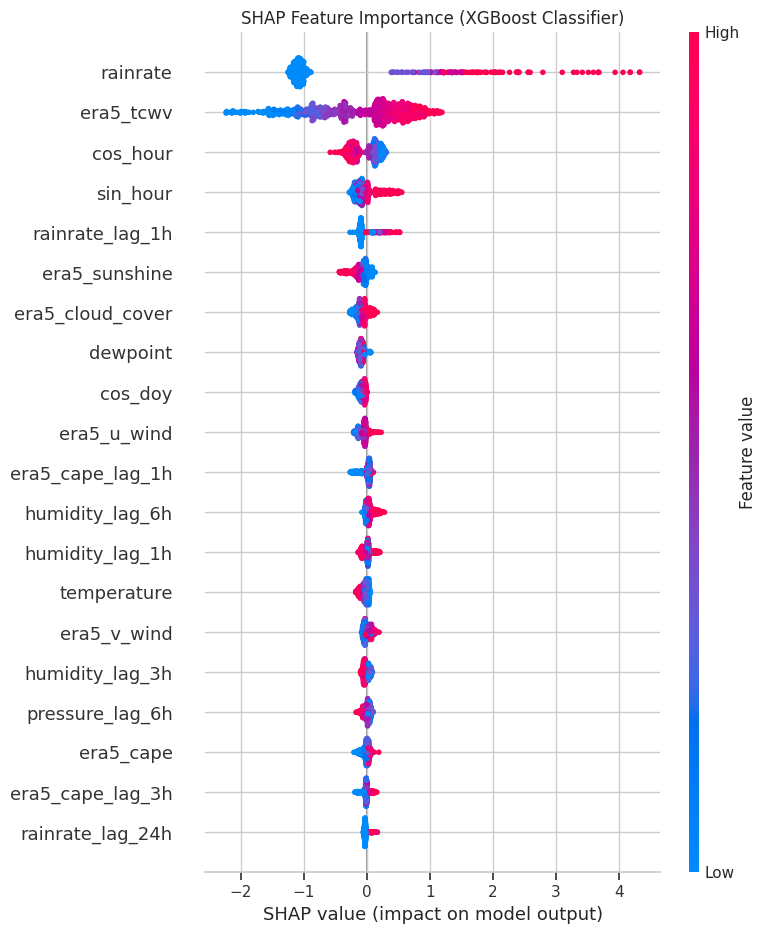

2026-07-07 16:34:01,911 - INFO - Plot SHAP berhasil disimpan!


In [19]:
# Sel Terakhir: Analisis SHAP (Feature Importance)
import shap
import matplotlib.pyplot as plt

logger.info("Membangkitkan plot SHAP untuk Model XGBoost...")

# Gunakan TreeExplainer yang sangat cepat untuk XGBoost
explainer = shap.TreeExplainer(clf_best)
# Ambil sampel dari Test Set untuk efisiensi
X_shap = X_test.sample(n=min(1000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, show=False)
plt.title('SHAP Feature Importance (XGBoost Classifier)')
plt.tight_layout()
plt.savefig(evaluator.dirs['plots'] / 'shap_summary_clf.png')
plt.show()

logger.info("Plot SHAP berhasil disimpan!")
